In [ ]:
from notebook_utils import cd2parent
cd2parent()

In [3]:
import pandas as pd
import os

from rdkit import Chem
from rdkit.Chem import Draw

from src.dataloader import Dataloader

# Loading raw data of core structures

In [4]:
dataloader = Dataloader()
dataloader.load_cores()

In [5]:
cores = dataloader.cores

In [6]:
cores['mol'] = cores['smiles'].apply(Chem.MolFromSmiles)

In [7]:
cores

,smiles,name,label,mol
0,C1NCC12CNO2,"1-oxa-2,6-diazaspiro[3.3]heptane",spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a0040>
1,C1NCC12CNC2,"2,6-diazaspiro[3.3]heptane",spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a0430>
2,C1NCC12COC2,2-oxa-6-azaspiro[3.3]heptane,spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a0e40>
3,C1CC2(CNC2)N1,"1,6-diazaspiro[3.3]heptane",spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a0dd0>
4,C1CNC2(C1)CNC2,"2,5-diazaspiro[3.4]octane",spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a0f20>
...,...,...,...,...
66,C1NCC12CN2,"1,5-diazaspiro[2.3]hexane",spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a2c70>
67,C1CC12CNC2,5-azaspiro[2.3]hexane,spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a2ce0>
68,C1CC2(C1)CO2,1-oxaspiro[2.3]hexane,spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a2dc0>
69,C1CC2(C1)CN2,1-azaspiro[2.3]hexane,spiro,<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a2d50>


# Figures

A series of pictures are drawn where the number of `max_mols` with further parameters (see cell code below) are choosen

In [8]:
n_cores = len(cores)
max_mols = 15
rows=3
columns = 5
n_rest = n_cores % max_mols
list_rest = [n_rest] if n_rest > 0 else []

mol_per_figure = [max_mols] * (n_cores // max_mols) + list_rest

In [9]:
mol_per_figure

[15, 15, 15, 15, 11]

In [10]:
start = 0
ranges = [(start := start, start := start + n)[0:2] for n in mol_per_figure]

In [12]:
figures = [
    Draw.MolsToGridImage(
        cores.loc[start:end-1, 'mol'],
        # legends=cores.loc[start:end-1, 'label'].fillna('na').tolist(),
        legends = cores.loc[start:end-1, ['name','label']].apply(
            lambda x: x['name'] + '\n' + x['label'], axis=1
            ).tolist(),
        molsPerRow=columns)
    for start,end in ranges
]

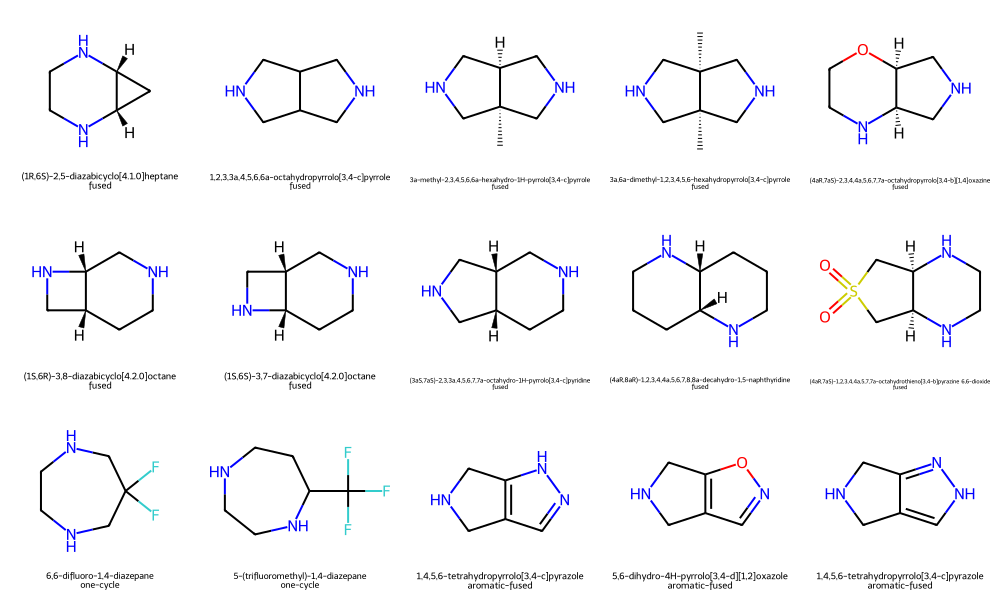

In [13]:
figures[2]

# Representative cores per type

Molecular structures are **grouped by** cycle type

In [14]:
grp_type = cores.groupby('label').agg(tuple)

In [15]:
grp_type

,smiles,name,mol
label,,,
aromatic-fused,"(c1n[nH]c2c1CNC2, c1noc2c1CNC2, c1[nH]nc2c1CNC2)","(1,4,5,6-tetrahydropyrrolo[3,4-c]pyrazole, 5,6...",(<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a21...
aromatic-one-cycle,"(c1cnoc1, c1ccoc1, c1cc[nH]c1, c1ccncc1)","(1,2-oxazole, furan, 1H-pyrrole, pyridine)",(<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a26...
bridged,"(C1NC2CNC1C2, C1CC2CNC1CN2, C1CC2CNCC1N2, C1NC...","(2,5-diazabicyclo[2.2.1]heptane, 2,5-diazabicy...",(<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a10...
bridged&fused,"(C1CC2CNC1[C@H]1CNC[C@@H]21, C1CC2NCC1C1CNCC21)","(octahydro-1H-4,7-(epiminomethano)isoindole, 4...",(<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a13...
fused,"(C1NC[C@H]2N[C@@H]12, C1CN[C@@H]2C[C@@H]2N1, C...","((1R,5S)-3,6-diazabicyclo[3.1.0]hexane, (1R,6S...",(<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a1c...
one-cycle,"(FC1(F)CNCCNC1, FC(F)(F)C1CCNCCN1, C1CNCCN1, C...","(6,6-difluoro-1,4-diazepane, 5-(trifluoromethy...",(<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a20...
spiro,"(C1NCC12CNO2, C1NCC12CNC2, C1NCC12COC2, C1CC2(...","(1-oxa-2,6-diazaspiro[3.3]heptane, 2,6-diazasp...",(<rdkit.Chem.rdchem.Mol object at 0x7fd8c25a00...


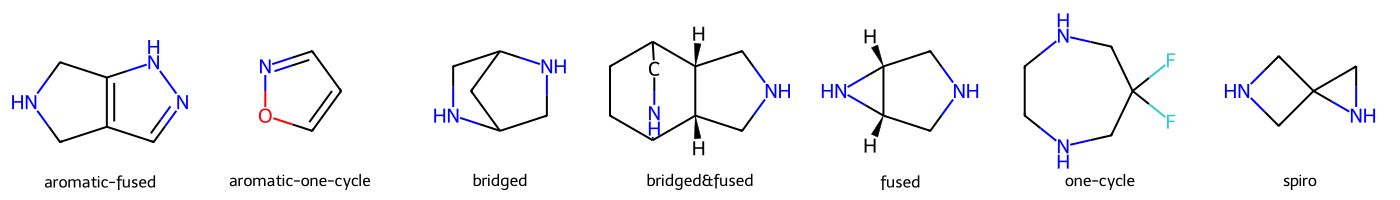

In [16]:
Draw.MolsToGridImage(
    [ row.mol[0] if typ!='spiro' else row.mol[30]
        for typ,row in grp_type.iterrows()
	],
    legends=grp_type.index.tolist(), molsPerRow=7, subImgSize=(200,200)
)

In [17]:
figures_per_type=[]
for typ,row in grp_type.iterrows():
    fig = Draw.MolsToGridImage(row.mol, molsPerRow=6,)
    figures_per_type.append(fig)

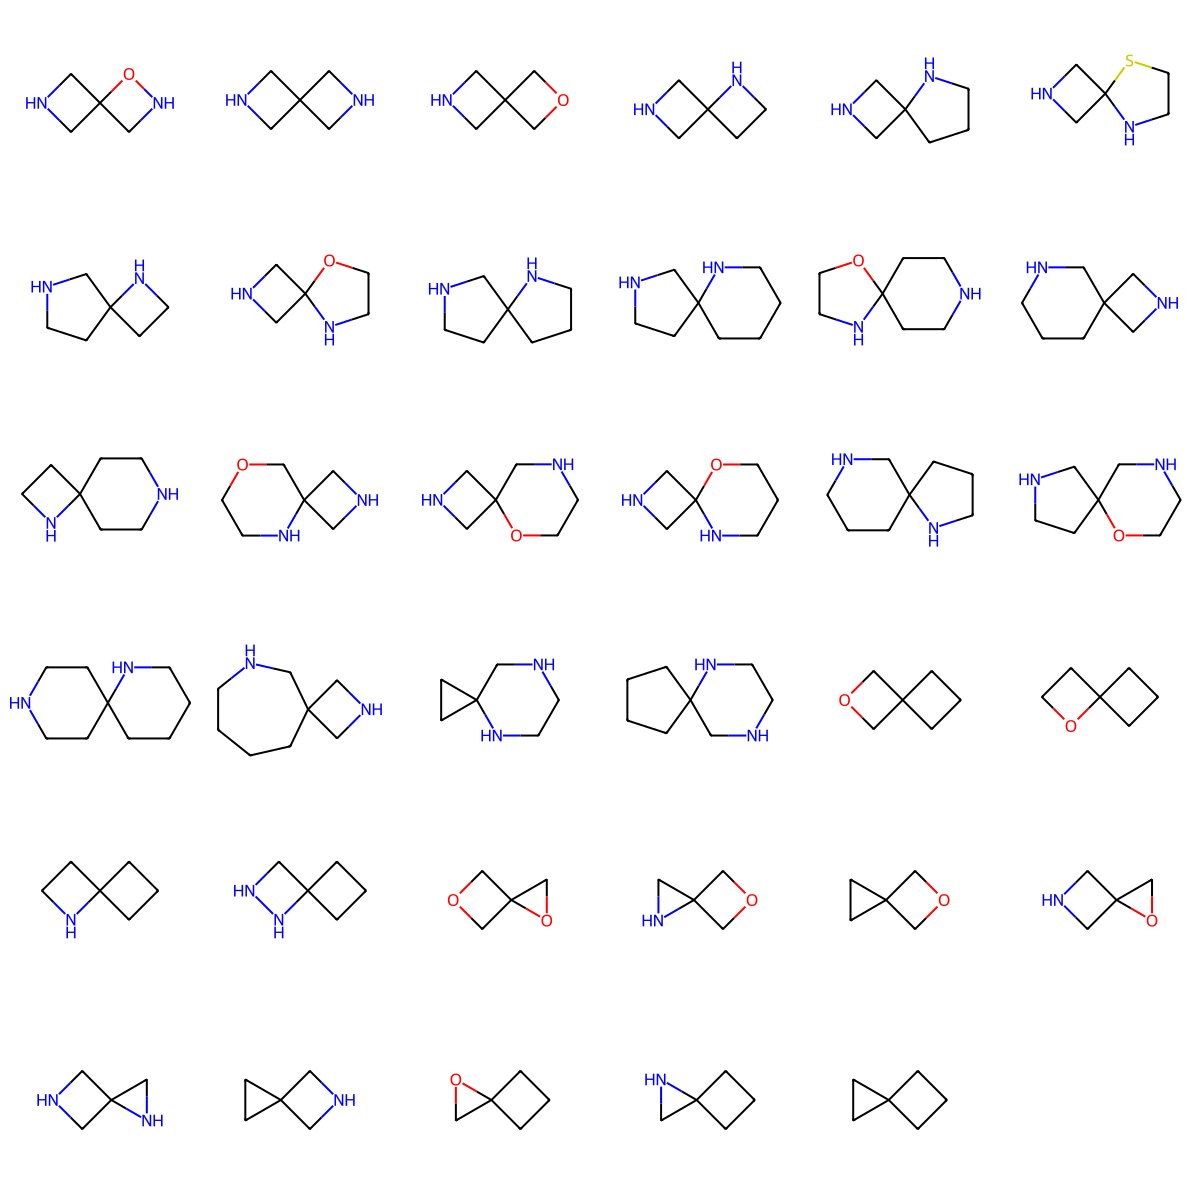

In [24]:
figures_per_type[6]